# AutoGluon.TimeSeries V1.4 Cheatsheet

This notebook contains the key code snippets from the AutoGluon Time Series cheatsheet.

## Installation

AutoGluon (GitHub) supports Python 3.9 to 3.12 and is available for Linux, macOS, and Windows. The fastest way to install AutoGluon is through the `uv` package manager.

```bash
# Install uv package manager (faster than pip)
# !python -m pip install -U uv

# Install AutoGluon
# !uv pip install autogluon

# Or install with pip
# !python -m pip install autogluon
```

## Preparing Data

AutoGluon can generate forecasts for datasets consisting of **multiple univariates** time series. Here we use the M4 Competition Daily dataset to demonstrate how to do forecasting with AutoGluon. 

The data typically requires two parts: **raw data** (time series) and **static features** (metadata).

In [1]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

# 1. Load the raw time series data (time series values)
# NOTE: You would replace 'm4_daily.csv' with your own dataset path.
raw_data = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_daily_subset/train.csv")
print("Raw Data Head:")
print(raw_data.head())

# 2. Load the static features (metadata for each time series ID)
static_features = pd.read_csv("https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_daily_subset/metadata.csv")
print("\nStatic Features Head:")
print(static_features.head())

/Users/sergio/code/automl_data_science/.env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Raw Data Head:
  item_id   timestamp  target
0   D1737  1995-05-23  1900.0
1   D1737  1995-05-24  1877.0
2   D1737  1995-05-25  1873.0
3   D1737  1995-05-26  1859.0
4   D1737  1995-05-27  1876.0

Static Features Head:
  item_id    domain
0   D1737  Industry
1   D1843  Industry
2   D2246   Finance
3    D909     Micro
4   D1345     Micro


In [2]:
print("# numero de series de tiempo : ",raw_data['item_id'].nunique())  # Number of unique time series IDs

# numero de series de tiempo :  100


In [9]:
static_features.groupby('domain').count()

,item_id
domain,
Finance,36
Industry,11
Macro,2
Micro,43
Other,8


### Convert Raw Data into a TimeSeriesDataFrame

Convert your raw data into the format required by AutoGluon: `TimeSeriesDataFrame`.

In [11]:
# from autogluon.timeseries import TimeSeriesDataFrame # Already imported above
data = TimeSeriesDataFrame(
    raw_data,
    id_column="item_id",
    timestamp_column="timestamp",
    static_features=static_features,  # Optional metadata/covariates
)

train_data,test_data=data.train_test_split(prediction_length=30)
print("Processed Training Data:")
print(data.head())

Sorting the dataframe index before generating the train/test split.


Processed Training Data:
                    target
item_id timestamp         
D1737   1995-05-23  1900.0
        1995-05-24  1877.0
        1995-05-25  1873.0
        1995-05-26  1859.0
        1995-05-27  1876.0


In [12]:
train_data.shape,test_data.shape

((241460, 1), (244460, 1))

In [13]:
train_data.freq,test_data.freq

('D', 'D')

In [15]:
train_data.tail()

target
item_id timestamp          
D979    2012-08-21  1099.80
        2012-08-22  1097.88
        2012-08-23  1115.30
        2012-08-24  1107.36
        2012-08-25  1106.26

In [16]:
test_data.tail()

target
item_id timestamp          
D979    2012-09-20  1091.86
        2012-09-21  1085.58
        2012-09-22  1083.10
        2012-09-23  1080.93
        2012-09-24  1090.88

## Training

Train models to forecast the values in the column `target` $30$ steps into the future.

In [17]:
# from autogluon.timeseries import TimeSeriesPredictor # Already imported above

predictor = TimeSeriesPredictor(
    target="target",
    prediction_length=30, # The number of time steps into the future to forecast
    # Optional: Additional covariates that are known in the future
    # known_covariates_names=['weekday', 'month'],
).fit(
    train_data,
    # Presets control the model quality and training time
    presets="medium_quality",
    # Other options: tuning metric, time limit, hyperparamter adjustment, etc.
    # eval_metric="MAPE",
    # time_limit=600,
    # verbosity=2
)

Beginning AutoGluon training...
AutoGluon will save models to '/Users/sergio/code/automl_data_science/AutogluonModels/ag-20251009_232258'
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.9.22
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 24.6.0: Mon Jul 14 11:30:34 PDT 2025; root:xnu-11417.140.69~1/RELEASE_ARM64_T8103
CPU Count:          8
GPU Count:          1
Memory Avail:       2.01 GB / 8.00 GB (25.1%)
Disk Space Avail:   12.26 GB / 228.27 GB (5.4%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 30,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'target',
 'verbosity': 2}

Inferred time se

## Predicting

Forecast `prediction_length` steps into the future starting from the end of each time series in `train_data`.

In [ ]:
predictions = predictor.predict(
    train_data,
    # If you used known_covariates_names during training, pass them here:
    # known_covariates=known_covariates,
)

print("Forecasted Predictions Head:")
print(predictions.head())

# AutoGluon generates probabilistic forecasts that include:
# - mean_forecast - expected value of the time series
# - quantile_forecast - range of possible outcomes

# Predict on a new, unseen dataset
# predictions_test = predictor.predict_test_data(
#     test_data,
#     model_names=['DeepAR', 'ETS'], # Optional: specify which models to use
# )

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Forecasted Predictions Head:
                            mean           0.1           0.2           0.3  \
item_id timestamp                                                            
D1069   2012-12-21  12235.438003  12065.536194  12119.586033  12163.451702   
        2012-12-22  12240.793049  12031.682472  12105.181636  12154.929833   
        2012-12-23  12248.192041  12001.202407  12090.002975  12148.588912   
        2012-12-24  12249.114958  11979.108546  12075.039802  12145.300702   
        2012-12-25  12249.035434  11954.131960  12058.744830  12134.282828   

                             0.4           0.5           0.6           0.7  \
item_id timestamp                                                            
D1069   2012-12-21  12199.586414  12235.438003  12257.129191  12293.997057   
        2012-12-22  12194.635104  12240.793049  12267.125554  12313.441422   
        2012-12-23  12194.407013  12248.192041  12282.056414  12333.256595   
        2012-12-24  12192.634406  

## Model Understanding

Understand the contribution of each model.

In [19]:
leaderboard = predictor.leaderboard()
print(leaderboard)

                       model  score_val  pred_time_val  fit_time_marginal  \
0           WeightedEnsemble  -0.025156      63.913127           0.516102   
1  TemporalFusionTransformer  -0.025660       0.129177         279.547317   
2        Chronos[bolt_small]  -0.026123      43.374752           7.412919   
3                      Naive  -0.026386       3.050836           0.060603   
4                        ETS  -0.026922      17.358362           0.057068   
5           RecursiveTabular  -0.027113       0.562038          23.370175   
6                      Theta  -0.027426       3.596535           0.058781   
7              SeasonalNaive  -0.029492       0.066286           0.052405   
8              DirectTabular  -0.032010       1.027812         147.906789   

   fit_order  
0          9  
1          8  
2          7  
3          1  
4          5  
5          3  
6          6  
7          2  
8          4  


# Evaluate

In [22]:
# Evaluate test data if available
predictions_test = predictor.predict(
     test_data)

Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


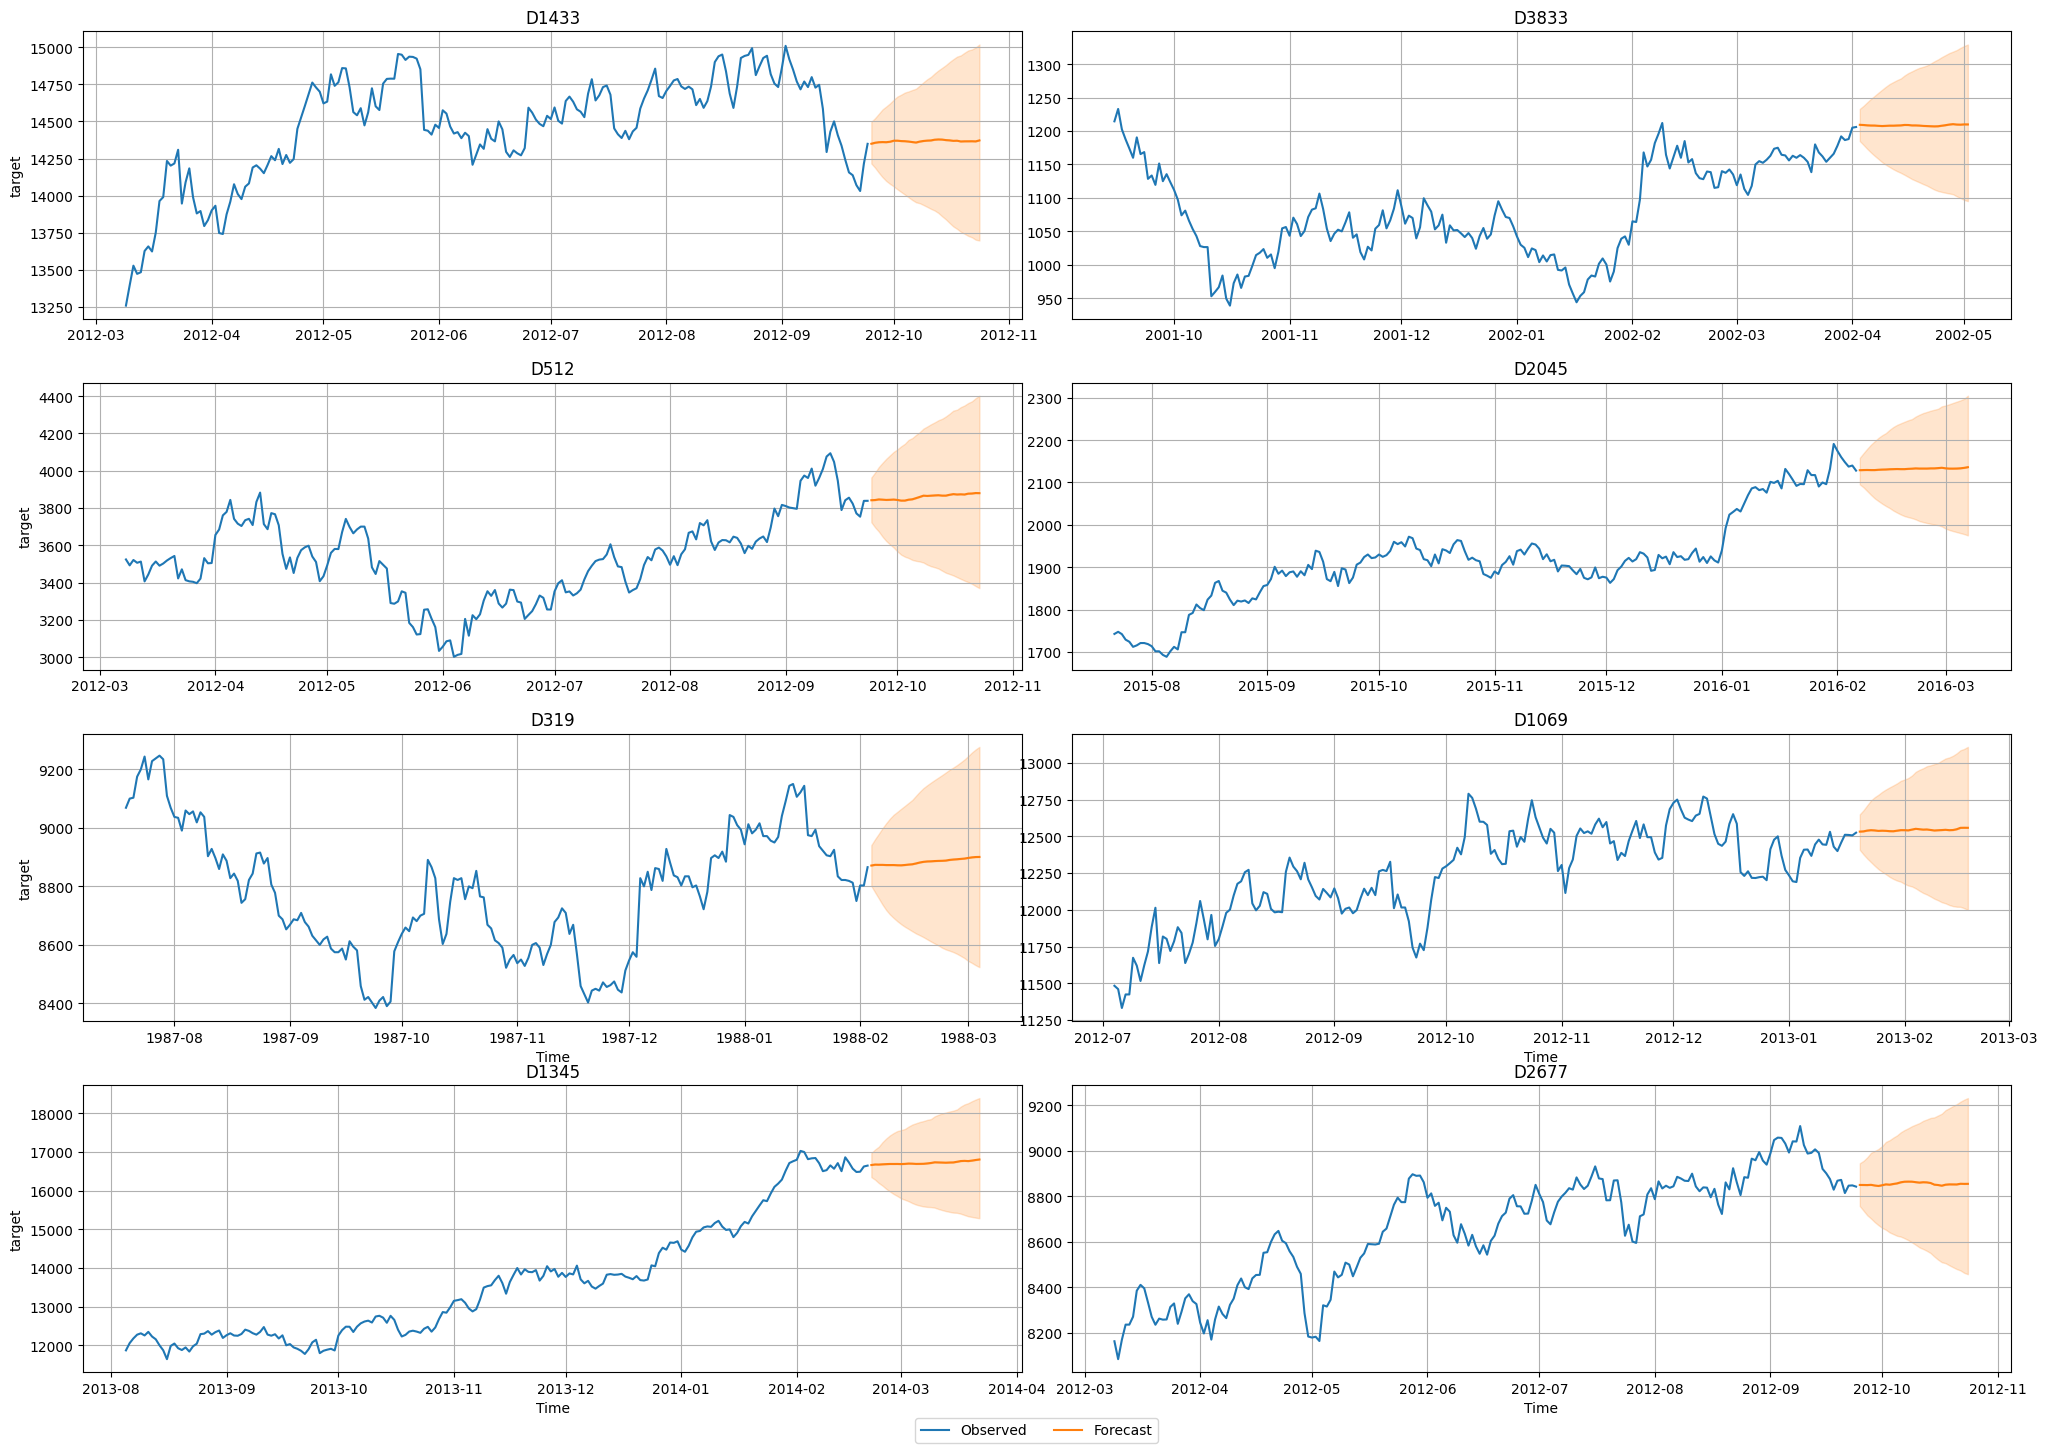

In [28]:
import matplotlib.pyplot as plt

plt.close('all')
predictor.plot(
    data=test_data,
    predictions=predictions_test,
    max_history_length=200,
);
plt.show()


In [24]:
test_data.shape

(244460, 1)